# LoRA From Scratch

**Problem it solves:** full fine-tuning updates every weight. For an 8B model that means holding the weights, the gradients, and the optimizer state in GPU memory at once — roughly 12–16× the model size — and you end up with a whole new multi-gigabyte model file per task.

**How it works:** freeze the original weight `W`. Learn two small matrices `A` and `B` instead, and use `W + B·A`. If the *change* you need is simple, two thin matrices can express it.

**When to use it:** whenever fine-tuning is the right answer at all — see the decision list in [4_fine_tuning_and_alignment.md](../4_fine_tuning_and_alignment.md). Almost nobody full-fine-tunes anymore.

NumPy only. We will test LoRA's central bet directly, then do the memory arithmetic that decides what fits on your GPU.

## Step 1 — A "pretrained" model and a new task

Our stand-in for a pretrained model is one big frozen matrix `W_base` (64 × 64). The new task needs slightly different behaviour: `W_target = W_base + (a small, low-rank change)`.

That is LoRA's whole bet, stated plainly:

> **the difference between "what the model does" and "what I need" is much simpler than the model itself.**

Here we build the new task so the true change has **rank 2**. Then we find out what different LoRA ranks can and cannot learn — which is the honest way to see when the bet holds and when it breaks.

In [1]:
import numpy as np
import matplotlib.pyplot as plt

rng = np.random.default_rng(0)

D = 64            # model width
TRUE_RANK = 2     # how complicated the change the new task really needs is

W_base = rng.normal(size=(D, D)) * 0.1              # "pretrained" weights - frozen forever

B_true = rng.normal(size=(D, TRUE_RANK)) * 0.3      # the change the new task needs...
A_true = rng.normal(size=(TRUE_RANK, D)) * 0.3      # ...which happens to be low-rank
W_target = W_base + B_true @ A_true

X = rng.normal(size=(512, D))                       # training data for the new task
Y = X @ W_target

X_test = rng.normal(size=(256, D))
Y_test = X_test @ W_target

print(f"W_base    : {W_base.shape} = {W_base.size:,} numbers (frozen)")
print(f"the change: rank {TRUE_RANK}, so it can be written with only "
      f"{TRUE_RANK * D * 2:,} numbers")
print(f"baseline loss if we change nothing: {np.mean((X_test @ W_base - Y_test) ** 2):.4f}")

W_base    : (64, 64) = 4,096 numbers (frozen)
the change: rank 2, so it can be written with only 256 numbers
baseline loss if we change nothing: 1.1774


## Step 2 — The LoRA layer

```
output = x · W        +  x · (B · A) · (alpha / r)
         ↑ frozen        ↑ trainable, tiny
```

Two details that matter in real code:

- **`B` starts at zero.** So `B·A = 0` and the adapted model starts out *identical* to the original. Training then moves away from it gently, instead of jolting the model with random noise on step one.
- **`alpha / r` is a scaling knob.** It lets you change the rank without re-tuning the learning rate.

In [2]:
def train_lora(rank, steps=600, lr=0.05, alpha=None):
    alpha = alpha if alpha is not None else rank        # common default: alpha = r
    scale = alpha / rank

    A = rng.normal(size=(rank, D)) * 0.02               # small random
    B = np.zeros((D, rank))                             # zero: the adapter starts as a no-op

    history = []
    for _ in range(steps):
        delta = (B @ A) * scale
        pred = X @ (W_base + delta)                     # W_base never changes
        error = pred - Y

        grad_delta = X.T @ error * (2 / len(X))         # gradient w.r.t. the combined change
        grad_B = grad_delta @ A.T * scale
        grad_A = B.T @ grad_delta * scale

        B -= lr * grad_B
        A -= lr * grad_A
        history.append(np.mean(error ** 2))

    test_loss = np.mean((X_test @ (W_base + (B @ A) * scale) - Y_test) ** 2)
    return A, B, history, test_loss


def train_full(steps=600, lr=0.05):
    '''Full fine-tuning: every one of the 4,096 weights is trainable.'''
    W = W_base.copy()
    history = []
    for _ in range(steps):
        error = X @ W - Y
        W -= lr * (X.T @ error * (2 / len(X)))
        history.append(np.mean(error ** 2))
    return W, history, np.mean((X_test @ W - Y_test) ** 2)


results = {}
for r in (1, 2, 4, 8):
    _, _, hist, test_loss = train_lora(r)
    results[f"LoRA r={r}"] = (hist, test_loss, 2 * D * r)

_, hist_full, test_full = train_full()
results["full fine-tune"] = (hist_full, test_full, D * D)

print(f"{'method':16s} {'trainable':>10s} {'% of layer':>11s} {'test loss':>11s}")
for name, (hist, test_loss, n_params) in results.items():
    print(f"{name:16s} {n_params:10,d} {100 * n_params / (D * D):10.1f}% {test_loss:11.5f}")

method            trainable  % of layer   test loss
LoRA r=1                128        3.1%     0.37973
LoRA r=2                256        6.2%     0.00000
LoRA r=4                512       12.5%     0.00000
LoRA r=8              1,024       25.0%     0.00000
full fine-tune        4,096      100.0%     0.00000


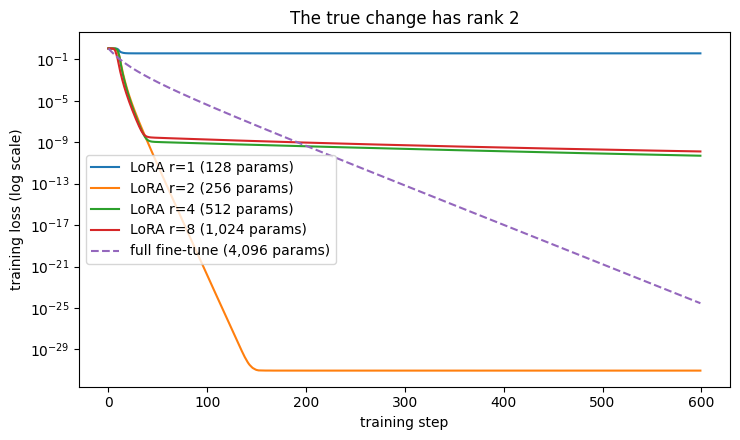

In [3]:
plt.figure(figsize=(7.5, 4.5))
for name, (hist, test_loss, n_params) in results.items():
    style = "--" if name == "full fine-tune" else "-"
    plt.plot(hist, style, label=f"{name} ({n_params:,} params)")

plt.yscale("log")
plt.xlabel("training step")
plt.ylabel("training loss (log scale)")
plt.title(f"The true change has rank {TRUE_RANK}")
plt.legend()
plt.tight_layout()
plt.show()

Read that carefully, because it is the entire idea:

- **`r = 1` cannot get there.** The adapter is too thin to express the change, no matter how long you train. That is what "the task needs more capacity" looks like.
- **`r = 2` matches full fine-tuning**, using 6% of the parameters — because the change really was rank 2.
- **`r = 4` and `r = 8` add capacity nobody needs.** No better, just more expensive, and on real data more likely to overfit.

That is the whole rank-choosing skill: rank is a guess about **how complicated your change is**, not a quality dial. Start at 8–16, raise it only when the training loss plateaus too high.

## Step 3 — Merging: LoRA costs nothing at inference time

After training you can fold the adapter into the frozen weights: `W_merged = W + B·A·(alpha/r)`. Now it is one ordinary matrix again — same speed, same shape, no extra work per token.

The trade-off: once merged, it is baked in. Keep it separate and you can hold twenty adapters for twenty tasks over **one** copy of the base model, and swap them per request. That is how a serving stack offers many fine-tunes without many GPUs.

In [4]:
A2, B2, _, _ = train_lora(rank=2)
W_merged = W_base + (B2 @ A2) * (2 / 2)

sample = X_test[:3]
out_adapter = sample @ (W_base + (B2 @ A2))
out_merged = sample @ W_merged

print("adapter kept separate vs merged - same numbers?",
      np.allclose(out_adapter, out_merged))
print(f"adapter file: {(A2.size + B2.size) * 4 / 1024:.1f} KB")
print(f"merged model file: {W_merged.size * 4 / 1024:.1f} KB")
print("\nAt real scale that is a few MB of adapter against ~16 GB of model.")

adapter kept separate vs merged - same numbers? True
adapter file: 1.0 KB
merged model file: 16.0 KB

At real scale that is a few MB of adapter against ~16 GB of model.


## Step 4 — Catastrophic forgetting, on purpose

The frozen weights are untouched, but the *behaviour* is not. Train the adapter hard on the new task and the model gets worse at the old one. On a real model this shows up as "we fine-tuned it for support tickets and now it is bad at everything else".

Below, the old task is simply what `W_base` used to do. Watch the two losses move in opposite directions.

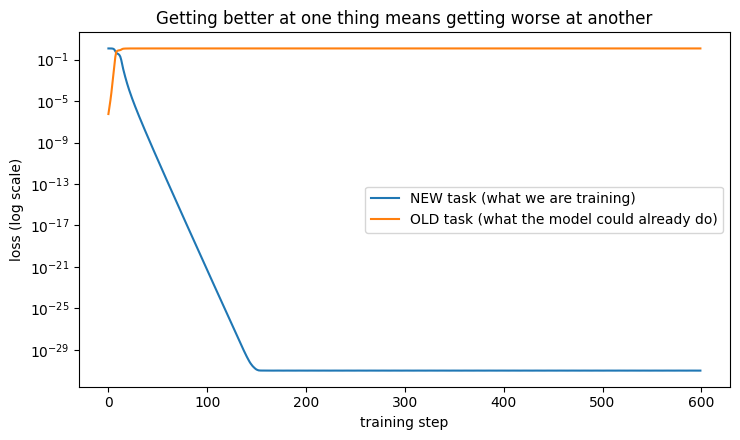

old-task loss at the start: 0.0000
old-task loss at the end  : 1.1774  <- this is forgetting

The defence is boring and effective: keep a small set of general questions,
score them before and after training, and stop when that score starts to drop.


In [5]:
Y_old_task = X_test @ W_base          # what the model USED to produce

A3 = rng.normal(size=(2, D)) * 0.02
B3 = np.zeros((D, 2))
new_task_loss, old_task_loss = [], []

for step in range(600):
    delta = B3 @ A3
    error = X @ (W_base + delta) - Y
    grad_delta = X.T @ error * (2 / len(X))
    grad_B, grad_A = grad_delta @ A3.T, B3.T @ grad_delta
    B3 -= 0.05 * grad_B
    A3 -= 0.05 * grad_A

    new_task_loss.append(np.mean((X_test @ (W_base + B3 @ A3) - Y_test) ** 2))
    old_task_loss.append(np.mean((X_test @ (W_base + B3 @ A3) - Y_old_task) ** 2))

plt.figure(figsize=(7.5, 4.5))
plt.plot(new_task_loss, label="NEW task (what we are training)")
plt.plot(old_task_loss, label="OLD task (what the model could already do)")
plt.yscale("log")
plt.xlabel("training step")
plt.ylabel("loss (log scale)")
plt.title("Getting better at one thing means getting worse at another")
plt.legend()
plt.tight_layout()
plt.show()

print(f"old-task loss at the start: {old_task_loss[0]:.4f}")
print(f"old-task loss at the end  : {old_task_loss[-1]:.4f}  <- this is forgetting")
print("\nThe defence is boring and effective: keep a small set of general questions,")
print("score them before and after training, and stop when that score starts to drop.")

## Step 5 — The memory bill: full vs LoRA vs QLoRA

This is the arithmetic that decides whether you can train on the GPU you actually have.

Training with Adam needs, for every **trainable** parameter: the weight, its gradient, and two optimizer states. In 16-bit that is roughly 16 bytes per trainable parameter. Frozen weights only cost their own storage.

In [6]:
def training_memory_gb(params_b, trainable_fraction, base_bytes=2):
    frozen_gb = params_b * 1e9 * base_bytes / 1e9              # the weights themselves
    trainable = params_b * 1e9 * trainable_fraction
    train_gb = trainable * 16 / 1e9                            # weight+grad+2 optimizer states
    return frozen_gb, train_gb, frozen_gb + train_gb


SETUPS = [
    ("full fine-tune, 16-bit", 1.0, 2),
    ("LoRA r=16, 16-bit base", 0.002, 2),
    ("QLoRA r=16, 4-bit base", 0.002, 0.5),
]

for params_b in (8, 70):
    print(f"\n=== {params_b}B model ===")
    for name, frac, base_bytes in SETUPS:
        frozen, train, total = training_memory_gb(params_b, frac, base_bytes)
        fits = "fits on one 80 GB GPU" if total < 80 else "needs multiple GPUs"
        print(f"  {name:24s} weights {frozen:6.1f} GB + training {train:6.1f} GB "
              f"= {total:6.1f} GB  ({fits})")

print("\n(Activations add more on top - this is the floor, not the ceiling.)")
print("This table is the reason QLoRA became the default starting point in 2026.")


=== 8B model ===
  full fine-tune, 16-bit   weights   16.0 GB + training  128.0 GB =  144.0 GB  (needs multiple GPUs)
  LoRA r=16, 16-bit base   weights   16.0 GB + training    0.3 GB =   16.3 GB  (fits on one 80 GB GPU)
  QLoRA r=16, 4-bit base   weights    4.0 GB + training    0.3 GB =    4.3 GB  (fits on one 80 GB GPU)

=== 70B model ===
  full fine-tune, 16-bit   weights  140.0 GB + training 1120.0 GB = 1260.0 GB  (needs multiple GPUs)
  LoRA r=16, 16-bit base   weights  140.0 GB + training    2.2 GB =  142.2 GB  (needs multiple GPUs)
  QLoRA r=16, 4-bit base   weights   35.0 GB + training    2.2 GB =   37.2 GB  (fits on one 80 GB GPU)

(Activations add more on top - this is the floor, not the ceiling.)
This table is the reason QLoRA became the default starting point in 2026.


## Your turn — modify and debug on purpose

Guess first, then run.

1. Set `TRUE_RANK = 8` in Step 1 and re-run Steps 1–2. Which ranks can keep up now? What does that tell you about picking `r` for a task you do not understand yet?
2. In Step 2, initialise `B` with `rng.normal(...)` instead of zeros. Watch the first few loss values. Why do real LoRA implementations always start `B` at zero?
3. In Step 2, set `alpha = rank * 4`. What changes — the final loss, or how fast it gets there? Which knob is `alpha` really behaving like?
4. In Step 4, cut training to 100 steps. Is the new-task loss good enough, and how much less forgetting did you get? This trade is the real reason "train less" is often the right call.
5. In Step 5, add a row for "LoRA r=64". Does the memory story change much? So what actually decides your rank — memory, or the task?
6. Without AI help, answer: *a teammate wants to fine-tune an 8B model so it knows your company's internal docs. Explain in your own words why that is probably the wrong tool, and what you would do instead.*